# 🛒 Amazon Sales Dataset — Pipeline de Análise Completo

> **Dataset:** `amazon_sales_dataset.csv` · 50.000 registros · 13 colunas  
> **Objetivo:** Limpeza, validação, transformação e visualização estratégica de dados de vendas

---

## 📋 Índice
1. [Configuração do Ambiente](#1)
2. [Ingestão e Inspeção Inicial](#2)
3. [Limpeza e Validação dos Dados](#3)
4. [Transformação e Feature Engineering](#4)
5. [📊 EDA — Análise Exploratória de Dados](#5)
6. [📉 Impacto de Descontos e Receita](#6)
7. [🌍 Tendências da Demanda Regional](#7)
8. [⭐ Análise de Avaliações e Satisfação](#8)
9. [Exportação do Dataset Limpo](#9)

---
## 1 · Configuração do Ambiente <a id='1'></a>

In [3]:
# ── Bibliotecas ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Estilo global ─────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='magma')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

MAGMA   = sns.color_palette('magma',  6)
ROCKET  = sns.color_palette('rocket', 6)
MUTED   = sns.color_palette('muted',  6)

FILE_PATH = 'amazon_sales_dataset.csv'

print('✅ Ambiente configurado com sucesso!')

✅ Ambiente configurado com sucesso!


---
## 2 · Ingestão e Inspeção Inicial <a id='2'></a>

In [9]:
# ── Carregamento ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv('amazon_sales_dataset.csv')

print(f'📐 Shape: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')
print(f'💾 Memória: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
df_raw.head()

📐 Shape: 50,000 linhas × 13 colunas
💾 Memória: 14.49 MB


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [10]:
# ── Tipos e nulos ─────────────────────────────────────────────────────────────
info = pd.DataFrame({
    'dtype'   : df_raw.dtypes,
    'nulos'   : df_raw.isnull().sum(),
    'nulos_%' : (df_raw.isnull().mean() * 100).round(2),
    'únicos'  : df_raw.nunique()
})
print(info.to_string())

                    dtype  nulos  nulos_%  únicos
order_id            int64      0      0.0   50000
order_date            str      0      0.0     730
product_id          int64      0      0.0    4000
product_category      str      0      0.0       6
price             float64      0      0.0   31465
discount_percent    int64      0      0.0       6
quantity_sold       int64      0      0.0       5
customer_region       str      0      0.0       4
payment_method        str      0      0.0       5
rating            float64      0      0.0      41
review_count        int64      0      0.0     500
discounted_price  float64      0      0.0   30356
total_revenue     float64      0      0.0   39768


In [11]:
# ── Estatísticas descritivas ──────────────────────────────────────────────────
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,50000.0,NaN,NaN,NaN,25000.5,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
order_date,50000,730,2023-10-19,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,50000.0,NaN,NaN,NaN,2986.84874,1156.374535,1000.0,1983.0,2983.0,3989.0,4999.0
product_category,50000,6,Beauty,8465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,50000.0,NaN,NaN,NaN,252.50726,143.025544,5.01,127.84,252.97,376.335,499.99
discount_percent,50000.0,NaN,NaN,NaN,13.3407,9.850694,0.0,5.0,10.0,20.0,30.0
quantity_sold,50000.0,NaN,NaN,NaN,2.9994,1.415401,1.0,2.0,3.0,4.0,5.0
customer_region,50000,4,Asia,12526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,50000,5,Wallet,10106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,50000.0,NaN,NaN,NaN,2.996316,1.154295,1.0,2.0,3.0,4.0,5.0


---
## 3 · Limpeza e Validação dos Dados <a id='3'></a>

In [12]:
df = df_raw.copy()

# ── 3.1 Tipagem correta ───────────────────────────────────────────────────────
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

cat_cols = ['product_category', 'customer_region', 'payment_method']
for col in cat_cols:
    df[col] = df[col].astype('category')

print('✅ Tipagem aplicada')
print(df.dtypes)

✅ Tipagem aplicada
order_id                     int64
order_date          datetime64[us]
product_id                   int64
product_category          category
price                      float64
discount_percent             int64
quantity_sold                int64
customer_region           category
payment_method            category
rating                     float64
review_count                 int64
discounted_price           float64
total_revenue              float64
dtype: object


In [13]:
# ── 3.2 Datas inválidas após parsing ─────────────────────────────────────────
datas_invalidas = df['order_date'].isnull().sum()
print(f'Datas inválidas após parsing: {datas_invalidas}')

# ── 3.3 Valores negativos em colunas numéricas ────────────────────────────────
num_cols = ['price', 'discount_percent', 'quantity_sold',
            'discounted_price', 'total_revenue', 'rating', 'review_count']

for col in num_cols:
    neg = (df[col] < 0).sum()
    if neg:
        print(f'  ⚠️  {col}: {neg} valor(es) negativo(s)')
    else:
        print(f'  ✅ {col}: sem negativos')

Datas inválidas após parsing: 0
  ✅ price: sem negativos
  ✅ discount_percent: sem negativos
  ✅ quantity_sold: sem negativos
  ✅ discounted_price: sem negativos
  ✅ total_revenue: sem negativos
  ✅ rating: sem negativos
  ✅ review_count: sem negativos


In [14]:
# ── 3.4 Validações de regras de negócio ───────────────────────────────────────

# Desconto deve ser entre 0 e 100
desc_fora = df[~df['discount_percent'].between(0, 100)]
print(f'Descontos fora do intervalo [0, 100]: {len(desc_fora)}')

# Rating deve ser entre 0 e 5
rating_fora = df[~df['rating'].between(0, 5)]
print(f'Ratings fora do intervalo [0, 5]: {len(rating_fora)}')

# Preço com desconto deve ser <= preço original
preco_inconsistente = df[df['discounted_price'] > df['price']]
print(f'Registros com discounted_price > price: {len(preco_inconsistente)}')

# Validação da coluna total_revenue (preço_desc × qtd)
df['_rev_calc'] = (df['discounted_price'] * df['quantity_sold']).round(2)
discrepancia = (df['total_revenue'].round(2) != df['_rev_calc']).sum()
print(f'Discrepâncias em total_revenue vs cálculo esperado: {discrepancia}')
df.drop(columns='_rev_calc', inplace=True)

Descontos fora do intervalo [0, 100]: 0
Ratings fora do intervalo [0, 5]: 0
Registros com discounted_price > price: 0
Discrepâncias em total_revenue vs cálculo esperado: 0


In [15]:
# ── 3.5 Duplicatas ────────────────────────────────────────────────────────────
dup_total = df.duplicated().sum()
dup_order = df.duplicated(subset='order_id').sum()

print(f'Linhas 100% duplicadas  : {dup_total}')
print(f'order_id duplicados     : {dup_order}')

if dup_total > 0:
    df.drop_duplicates(inplace=True)
    print(f'  → Duplicatas removidas. Novo shape: {df.shape}')
else:
    print('✅ Sem duplicatas — dataset íntegro')

Linhas 100% duplicadas  : 0
order_id duplicados     : 0
✅ Sem duplicatas — dataset íntegro


In [16]:
# ── 3.6 Outliers (IQR) ───────────────────────────────────────────────────────
def detectar_outliers_iqr(series, label):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n = ((series < lower) | (series > upper)).sum()
    pct = n / len(series) * 100
    print(f'  {label:<20} → {n:>5} outliers ({pct:.2f}%)  |  [{lower:.2f}, {upper:.2f}]')

print('Outliers por coluna (método IQR):')
for col in ['price', 'quantity_sold', 'total_revenue', 'review_count']:
    detectar_outliers_iqr(df[col], col)

Outliers por coluna (método IQR):
  price                →     0 outliers (0.00%)  |  [-244.90, 749.08]
  quantity_sold        →     0 outliers (0.00%)  |  [-1.00, 7.00]
  total_revenue        →   752 outliers (1.50%)  |  [-852.66, 2061.95]
  review_count         →     0 outliers (0.00%)  |  [-248.50, 747.50]


---
## 4 · Transformação e Feature Engineering <a id='4'></a>

In [17]:
# ── 4.1 Features temporais ────────────────────────────────────────────────────
df['year']    = df['order_date'].dt.year
df['month']   = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter
df['weekday'] = df['order_date'].dt.day_name()
df['month_label'] = df['order_date'].dt.strftime('%b %Y')

print('✅ Features temporais criadas:', ['year','month','quarter','weekday','month_label'])

✅ Features temporais criadas: ['year', 'month', 'quarter', 'weekday', 'month_label']


In [18]:
# ── 4.2 KPIs de negócio ───────────────────────────────────────────────────────

# Valor absoluto do desconto em $
df['discount_value'] = (df['price'] - df['discounted_price']).round(2)

# Receita perdida por desconto
df['revenue_lost'] = (df['discount_value'] * df['quantity_sold']).round(2)

# Receita potencial (sem desconto)
df['potential_revenue'] = (df['price'] * df['quantity_sold']).round(2)

# Faixa de desconto (segmentação)
bins   = [-1, 0, 10, 20, 30, 100]
labels = ['Sem Desconto', '1–10%', '11–20%', '21–30%', '31%+']
df['discount_tier'] = pd.cut(df['discount_percent'], bins=bins, labels=labels)

# Faixa de preço
df['price_tier'] = pd.cut(
    df['price'],
    bins=[0, 100, 250, 400, float('inf')],
    labels=['Baixo (<$100)', 'Médio ($100–250)', 'Alto ($250–400)', 'Premium ($400+)']
)

# Score de engajamento (rating normalizado × log(reviews))
df['engagement_score'] = (df['rating'] / 5) * np.log1p(df['review_count'])
df['engagement_score'] = df['engagement_score'].round(4)

print('✅ KPIs criados:')
for col in ['discount_value','revenue_lost','potential_revenue',
            'discount_tier','price_tier','engagement_score']:
    print(f'   · {col}')

✅ KPIs criados:
   · discount_value
   · revenue_lost
   · potential_revenue
   · discount_tier
   · price_tier
   · engagement_score


In [19]:
# ── Snapshot do dataset transformado ─────────────────────────────────────────
print(f'Shape final: {df.shape}')
df.head(3)

Shape final: (50000, 24)


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,...,month,quarter,weekday,month_label,discount_value,revenue_lost,potential_revenue,discount_tier,price_tier,engagement_score
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,...,4,2,Wednesday,Apr 2022,12.87,51.48,515.0,1–10%,Médio ($100–250),4.2671
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,...,3,1,Sunday,Mar 2023,60.52,302.60,1513.0,11–20%,Alto ($250–400),4.5624
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,...,9,3,Wednesday,Sep 2022,99.16,198.32,991.6,11–20%,Premium ($400+),4.5891


---
## 5 · 📊 EDA — Análise Exploratória de Dados <a id='5'></a>

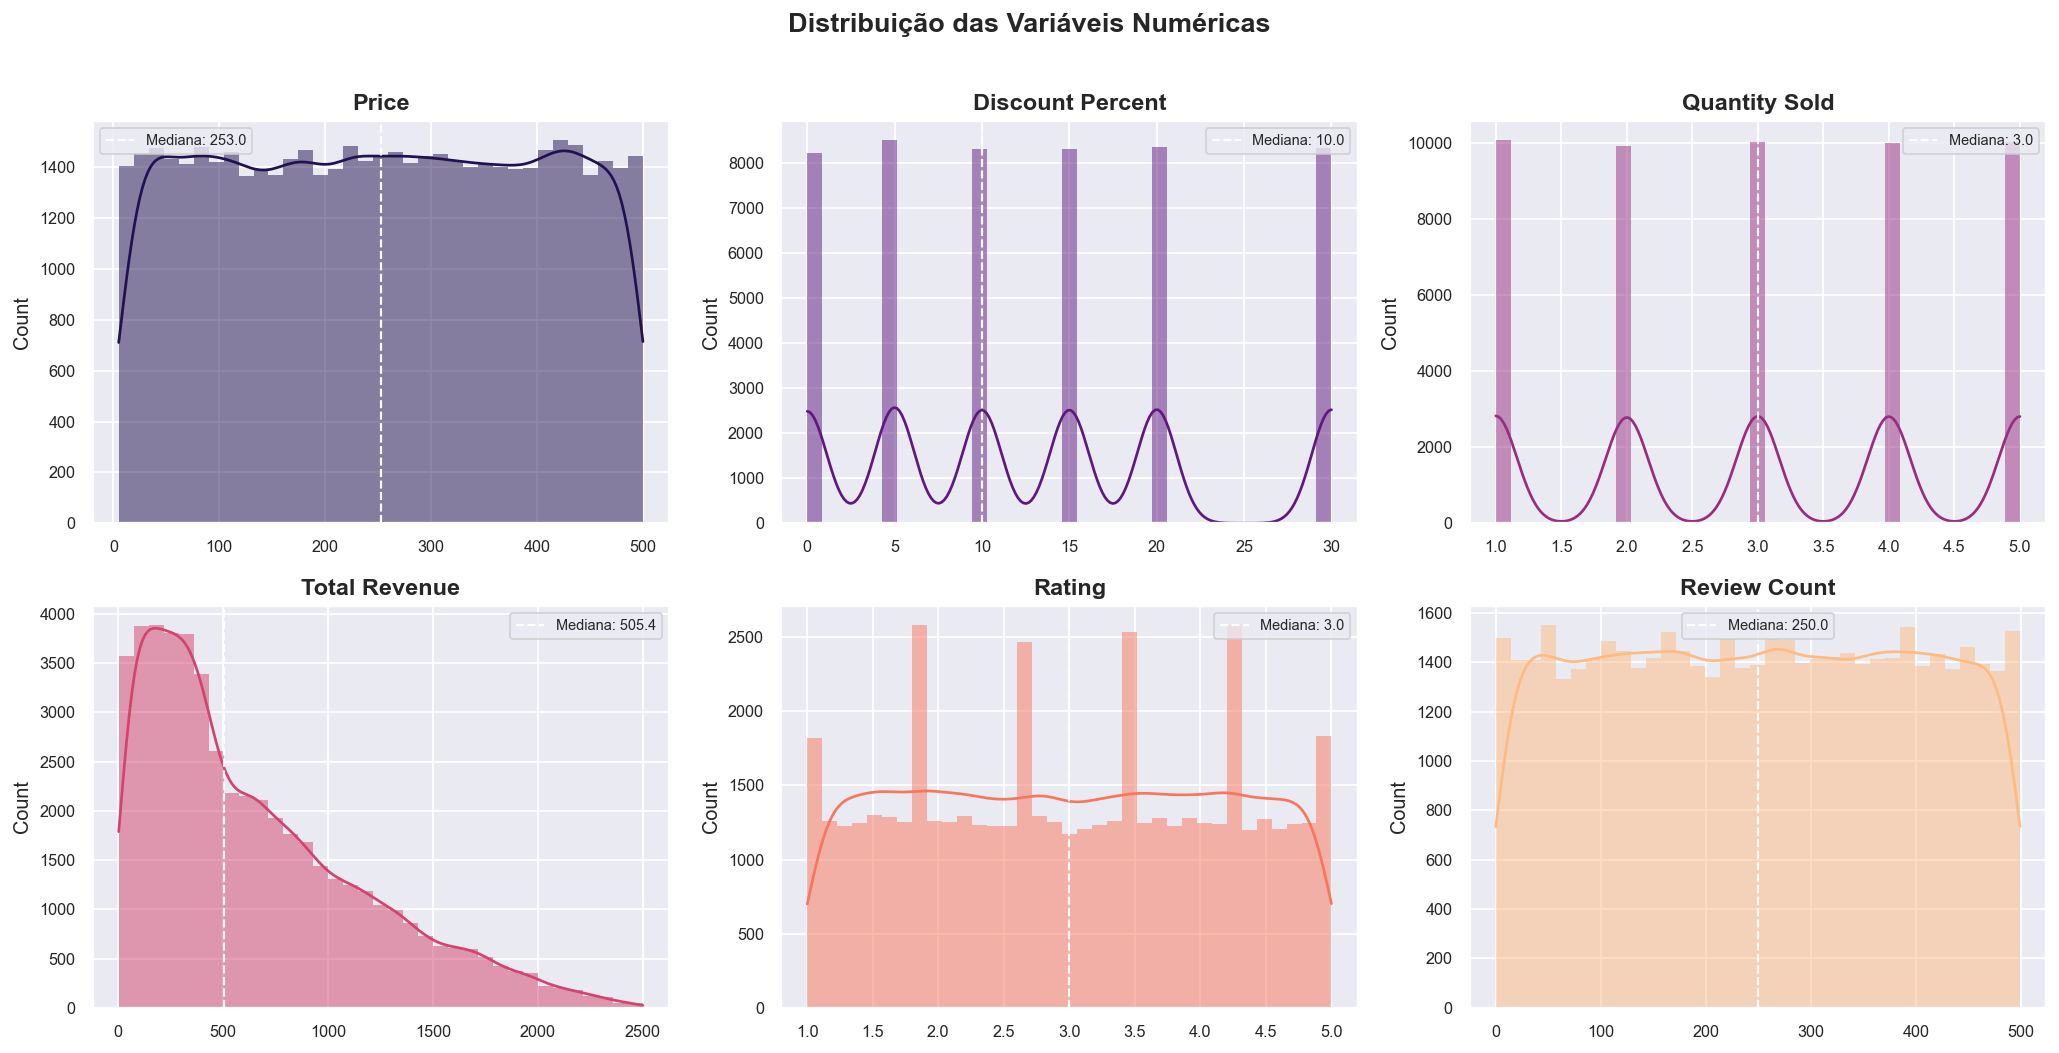

In [20]:
# ── 5.1 Distribuição de variáveis numéricas ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribuição das Variáveis Numéricas', fontsize=15, fontweight='bold', y=1.01)

cols_hist = ['price', 'discount_percent', 'quantity_sold',
             'total_revenue', 'rating', 'review_count']

for ax, col, color in zip(axes.flat, cols_hist, MAGMA):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=35, linewidth=0)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    median_val = df[col].median()
    ax.axvline(median_val, color='white', linestyle='--', linewidth=1.2,
               label=f'Mediana: {median_val:.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('dist_numericas.png', bbox_inches='tight')
plt.show()

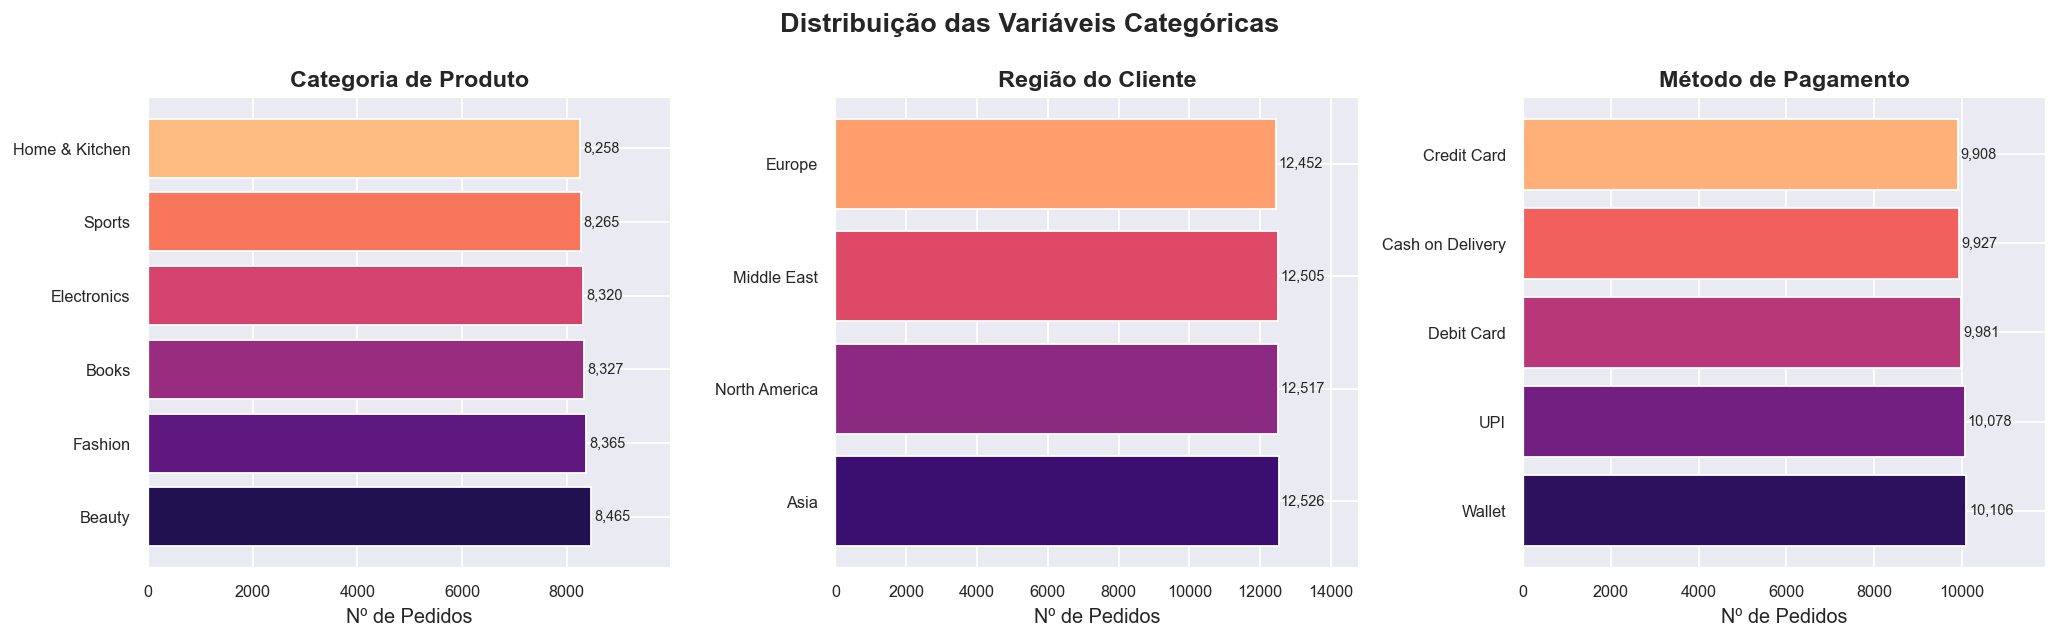

In [21]:
# ── 5.2 Distribuição de variáveis categóricas ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribuição das Variáveis Categóricas', fontsize=15, fontweight='bold')

cat_plot = [
    ('product_category', 'Categoria de Produto'),
    ('customer_region',  'Região do Cliente'),
    ('payment_method',   'Método de Pagamento'),
]

for ax, (col, title) in zip(axes, cat_plot):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values,
                   color=sns.color_palette('magma', len(counts)))
    ax.set_title(title)
    ax.set_xlabel('Nº de Pedidos')
    for bar in bars:
        ax.text(bar.get_width() + 60, bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():,.0f}', va='center', fontsize=8)
    ax.set_xlim(0, counts.max() * 1.18)

plt.tight_layout()
plt.savefig('dist_categoricas.png', bbox_inches='tight')
plt.show()

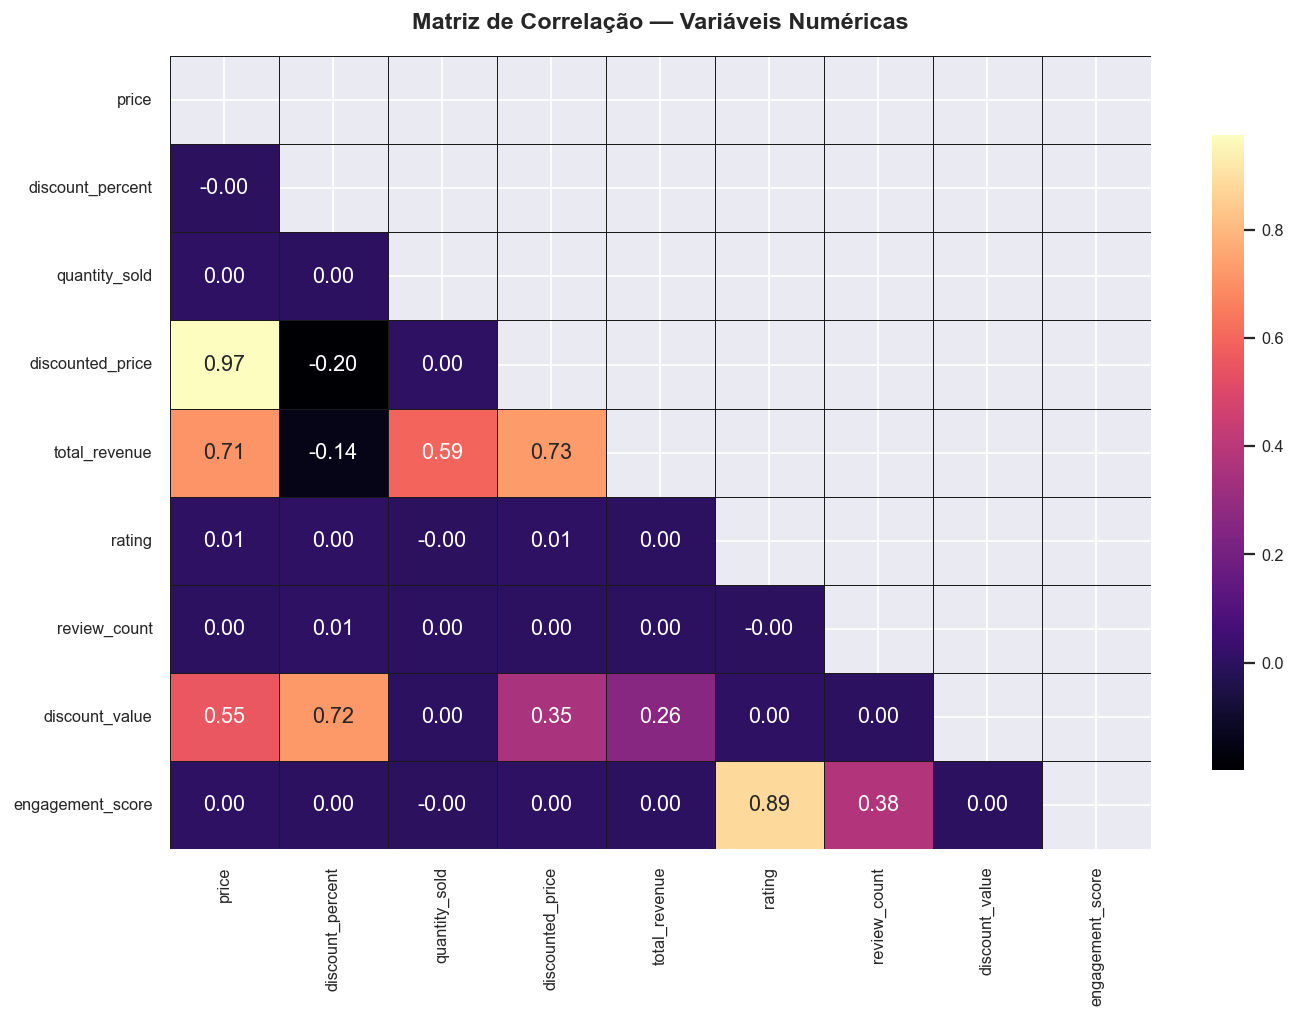

In [22]:
# ── 5.3 Matriz de correlação ──────────────────────────────────────────────────
num_df = df[['price', 'discount_percent', 'quantity_sold', 'discounted_price',
             'total_revenue', 'rating', 'review_count',
             'discount_value', 'engagement_score']]

corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='magma',
            linewidths=0.5, linecolor='#1a1a1a',
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de Correlação — Variáveis Numéricas', pad=15)
plt.tight_layout()
plt.savefig('heatmap_correlacao.png', bbox_inches='tight')
plt.show()

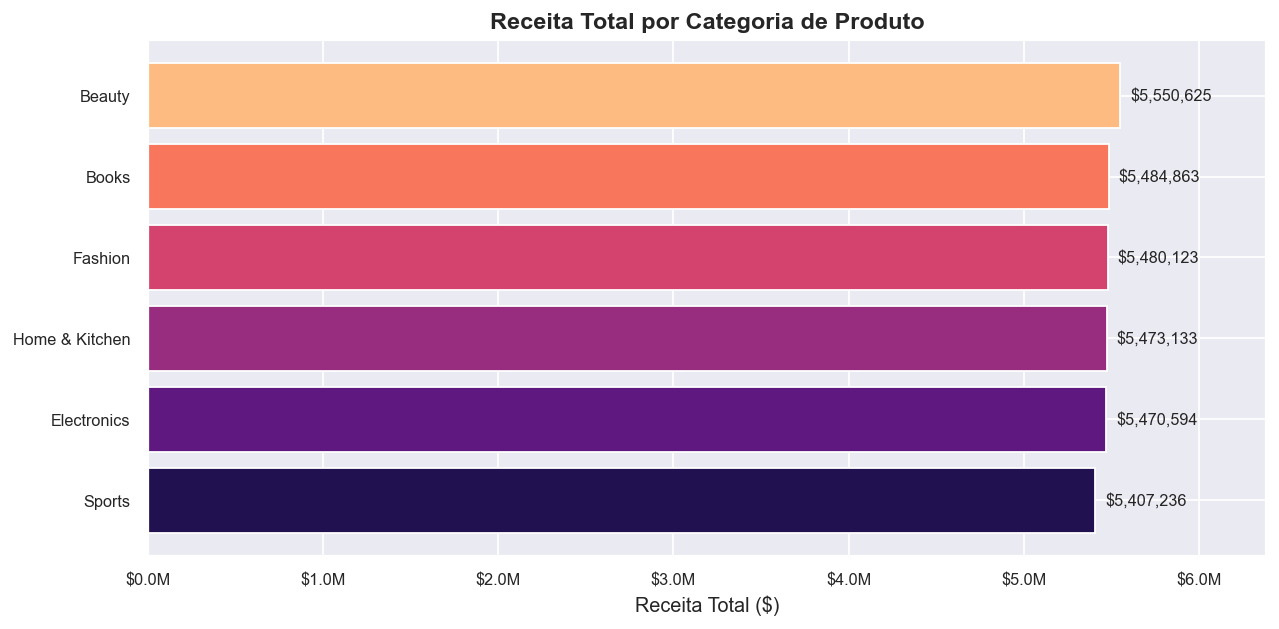

In [23]:
# ── 5.4 Receita total por categoria de produto ────────────────────────────────
receita_cat = (df.groupby('product_category', observed=True)['total_revenue']
                 .sum()
                 .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('magma', len(receita_cat))
bars = ax.barh(receita_cat.index, receita_cat.values, color=colors)

for bar in bars:
    ax.text(bar.get_width() + receita_cat.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'${bar.get_width():,.0f}', va='center', fontsize=9)

ax.set_title('Receita Total por Categoria de Produto')
ax.set_xlabel('Receita Total ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xlim(0, receita_cat.max() * 1.15)
plt.tight_layout()
plt.savefig('receita_categoria.png', bbox_inches='tight')
plt.show()

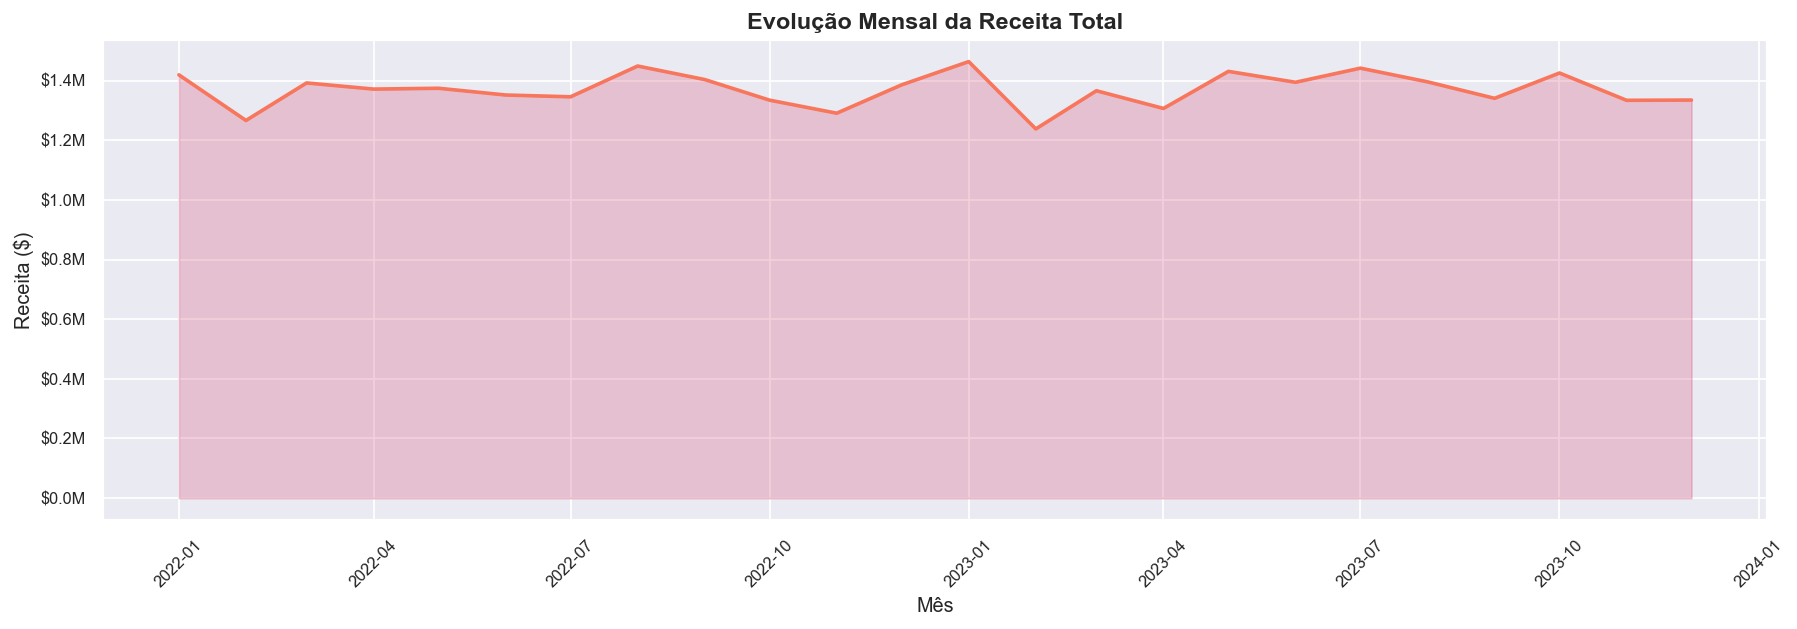

In [24]:
# ── 5.5 Evolução mensal da receita ────────────────────────────────────────────
receita_mensal = (df.groupby(df['order_date'].dt.to_period('M'))['total_revenue']
                    .sum()
                    .reset_index())
receita_mensal['order_date'] = receita_mensal['order_date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(receita_mensal['order_date'], receita_mensal['total_revenue'],
                alpha=0.25, color=MAGMA[3])
ax.plot(receita_mensal['order_date'], receita_mensal['total_revenue'],
        color=MAGMA[4], linewidth=2)
ax.set_title('Evolução Mensal da Receita Total')
ax.set_xlabel('Mês')
ax.set_ylabel('Receita ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('receita_mensal.png', bbox_inches='tight')
plt.show()

---
## 6 · 📉 Impacto de Descontos e Receita <a id='6'></a>

In [25]:
# ── 6.1 KPI Resumo — Desconto ─────────────────────────────────────────────────
receita_real      = df['total_revenue'].sum()
receita_potencial = df['potential_revenue'].sum()
receita_perdida   = df['revenue_lost'].sum()
pct_perdida       = receita_perdida / receita_potencial * 100

print('=' * 50)
print(f'  Receita Potencial (sem desc.)  : ${receita_potencial:>15,.2f}')
print(f'  Receita Real (com desc.)       : ${receita_real:>15,.2f}')
print(f'  Receita Perdida em Descontos   : ${receita_perdida:>15,.2f}')
print(f'  % Perda sobre Potencial        : {pct_perdida:>14.2f}%')
print('=' * 50)

  Receita Potencial (sem desc.)  : $  37,913,104.54
  Receita Real (com desc.)       : $  32,866,573.74
  Receita Perdida em Descontos   : $   5,046,530.80
  % Perda sobre Potencial        :          13.31%


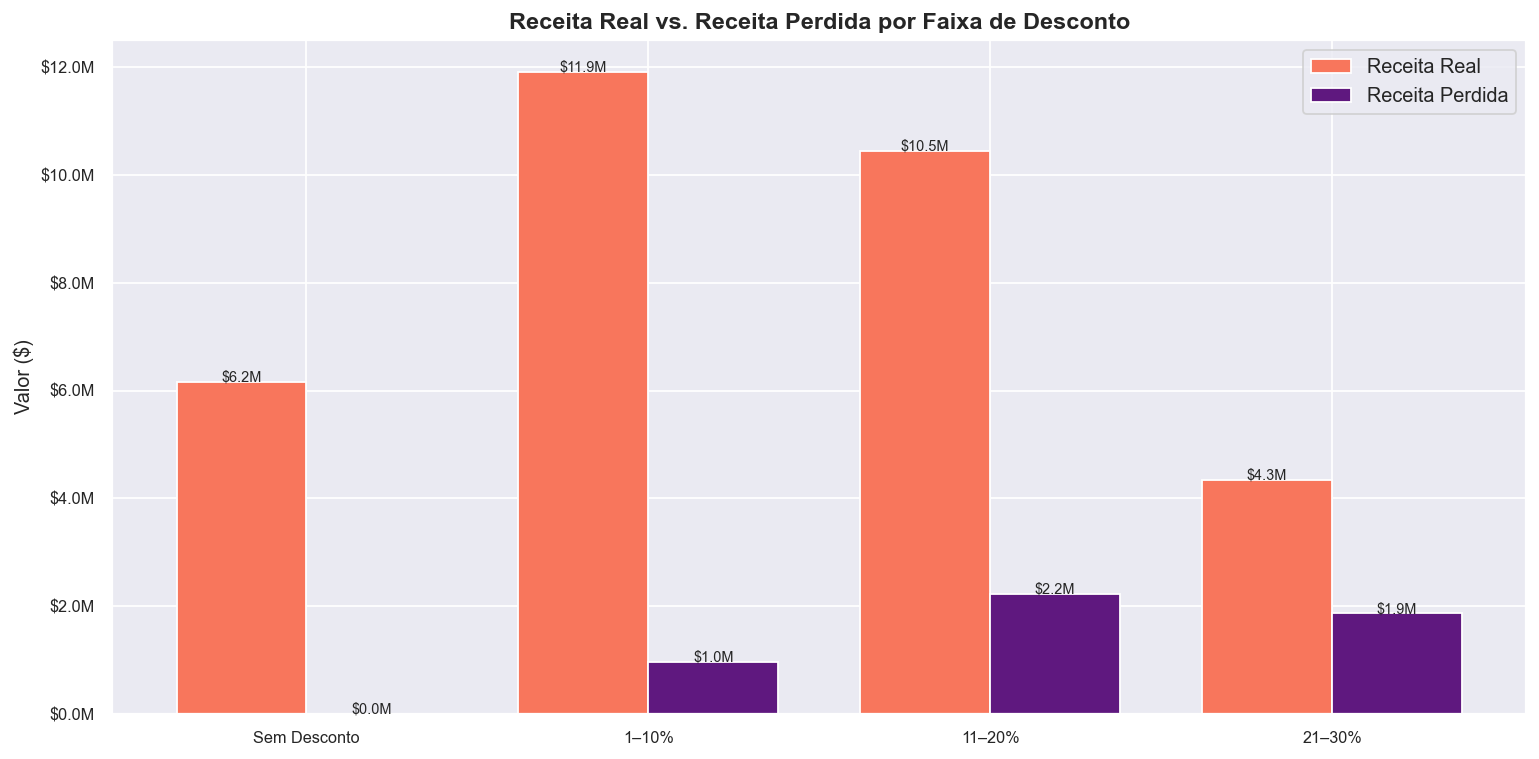

In [26]:
# ── 6.2 Receita real vs. perdida por faixa de desconto ───────────────────────
tier_rev = (df.groupby('discount_tier', observed=True)
              .agg(receita_real=('total_revenue', 'sum'),
                   receita_perdida=('revenue_lost', 'sum'),
                   n_pedidos=('order_id', 'count'))
              .reset_index())

x = np.arange(len(tier_rev))
w = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w/2, tier_rev['receita_real'],    w, label='Receita Real',    color=MAGMA[4])
b2 = ax.bar(x + w/2, tier_rev['receita_perdida'], w, label='Receita Perdida', color=MAGMA[1])

ax.set_title('Receita Real vs. Receita Perdida por Faixa de Desconto')
ax.set_xticks(x)
ax.set_xticklabels(tier_rev['discount_tier'])
ax.set_ylabel('Valor ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))
ax.legend()

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10000,
            f'${bar.get_height()/1e6:.1f}M',
            ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('desconto_receita.png', bbox_inches='tight')
plt.show()

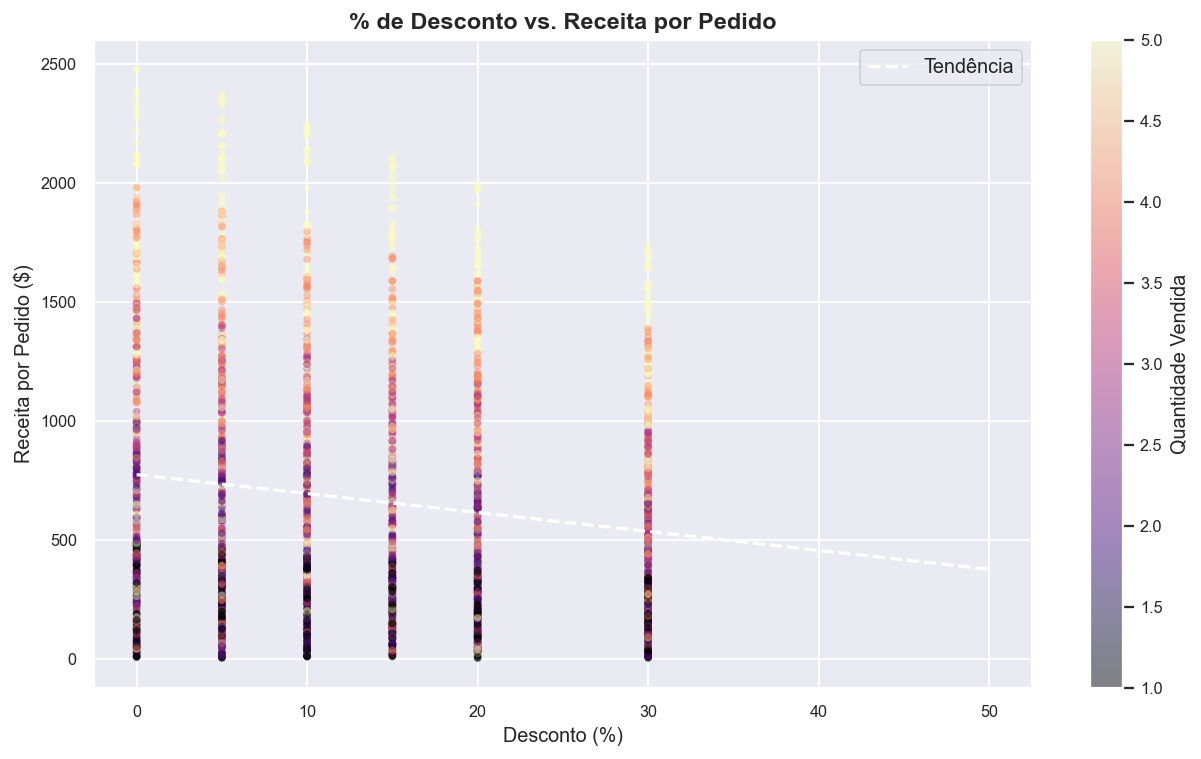

In [27]:
# ── 6.3 Relação entre % desconto e receita por pedido ────────────────────────
sample = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    sample['discount_percent'], sample['total_revenue'],
    c=sample['quantity_sold'], cmap='magma',
    alpha=0.45, s=18, edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Quantidade Vendida')

# Linha de tendência
z = np.polyfit(sample['discount_percent'], sample['total_revenue'], 1)
p = np.poly1d(z)
xs = np.linspace(0, 50, 200)
ax.plot(xs, p(xs), color='white', linewidth=1.8, linestyle='--', label='Tendência')

ax.set_title('% de Desconto vs. Receita por Pedido')
ax.set_xlabel('Desconto (%)')
ax.set_ylabel('Receita por Pedido ($)')
ax.legend()
plt.tight_layout()
plt.savefig('scatter_desconto_receita.png', bbox_inches='tight')
plt.show()

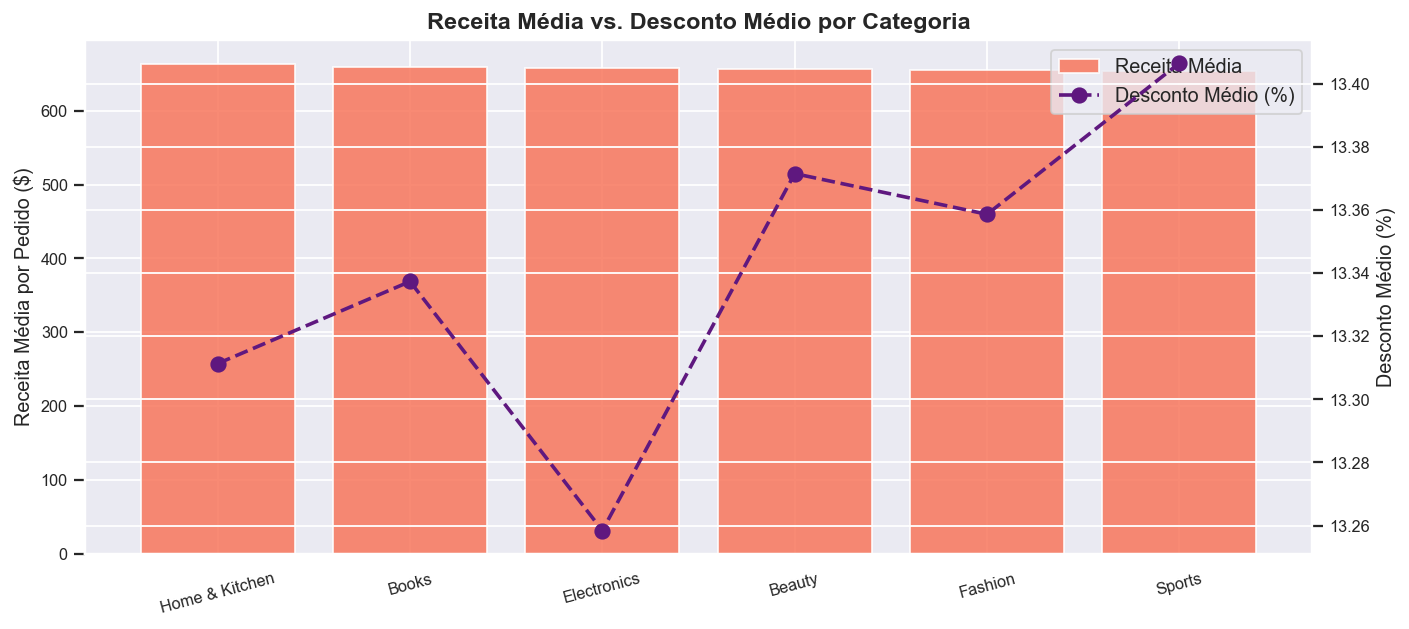

In [28]:
# ── 6.4 Desconto médio e receita média por categoria ─────────────────────────
cat_desc = (df.groupby('product_category', observed=True)
              .agg(
                  desconto_medio=('discount_percent', 'mean'),
                  receita_media=('total_revenue', 'mean')
              )
              .sort_values('receita_media', ascending=False)
              .reset_index())

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = np.arange(len(cat_desc))
bars = ax1.bar(x, cat_desc['receita_media'], color=MAGMA[4], alpha=0.85, label='Receita Média')
ax2.plot(x, cat_desc['desconto_medio'], 'o--', color=MAGMA[1],
         linewidth=2, markersize=8, label='Desconto Médio (%)')

ax1.set_xticks(x)
ax1.set_xticklabels(cat_desc['product_category'], rotation=15)
ax1.set_ylabel('Receita Média por Pedido ($)')
ax2.set_ylabel('Desconto Médio (%)')
ax1.set_title('Receita Média vs. Desconto Médio por Categoria')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('categoria_desconto_receita.png', bbox_inches='tight')
plt.show()

---
## 7 · 🌍 Tendências da Demanda Regional <a id='7'></a>

In [29]:
# ── 7.1 KPI Regional ─────────────────────────────────────────────────────────
regional_kpi = (df.groupby('customer_region', observed=True)
                  .agg(
                      total_pedidos=('order_id', 'count'),
                      receita_total=('total_revenue', 'sum'),
                      ticket_medio=('total_revenue', 'mean'),
                      desconto_medio=('discount_percent', 'mean'),
                      qtd_media=('quantity_sold', 'mean'),
                      rating_medio=('rating', 'mean')
                  )
                  .sort_values('receita_total', ascending=False))

regional_kpi['receita_total_M'] = (regional_kpi['receita_total'] / 1e6).round(2)
regional_kpi[['total_pedidos', 'receita_total_M', 'ticket_medio',
              'desconto_medio', 'qtd_media', 'rating_medio']].round(2)

,total_pedidos,receita_total_M,ticket_medio,desconto_medio,qtd_media,rating_medio
customer_region,,,,,,
Middle East,12505,8.30,663.88,13.23,3.01,3.02
North America,12517,8.28,661.28,13.30,3.00,3.00
Asia,12526,8.18,652.66,13.48,2.99,3.00
Europe,12452,8.11,651.49,13.35,3.00,2.97


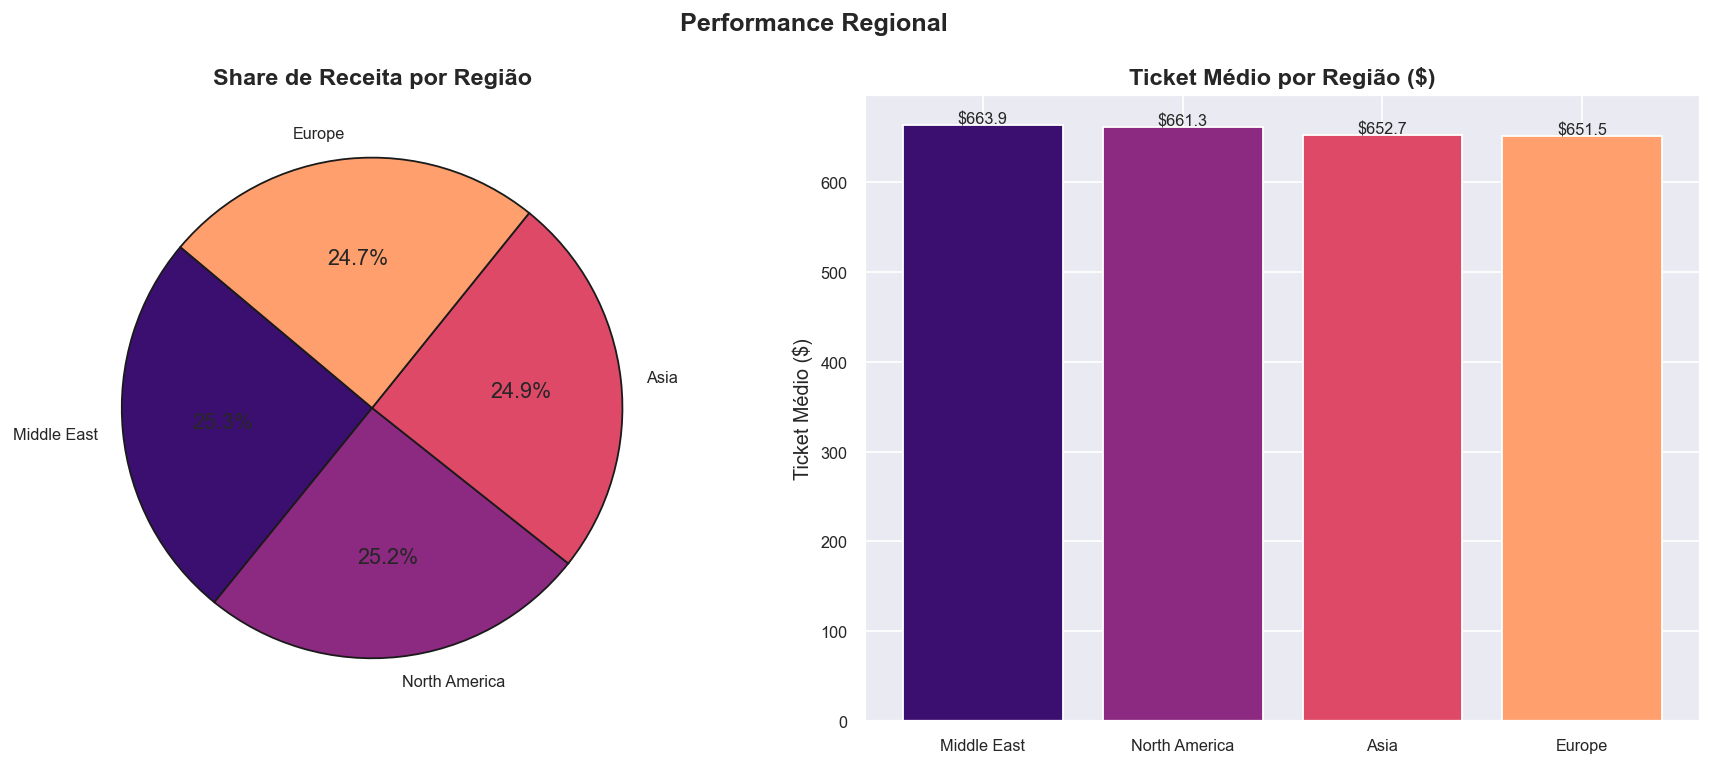

In [30]:
# ── 7.2 Receita total por região ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Performance Regional', fontsize=14, fontweight='bold')

reg = regional_kpi.reset_index().sort_values('receita_total', ascending=False)
colors = sns.color_palette('magma', len(reg))

# Pizza — share de receita
axes[0].pie(
    reg['receita_total'],
    labels=reg['customer_region'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': '#1a1a1a', 'linewidth': 1}
)
axes[0].set_title('Share de Receita por Região')

# Barras — ticket médio
bars = axes[1].bar(reg['customer_region'], reg['ticket_medio'], color=colors)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 2,
                 f'${bar.get_height():.1f}',
                 ha='center', fontsize=9)
axes[1].set_title('Ticket Médio por Região ($)')
axes[1].set_ylabel('Ticket Médio ($)')

plt.tight_layout()
plt.savefig('regional_overview.png', bbox_inches='tight')
plt.show()

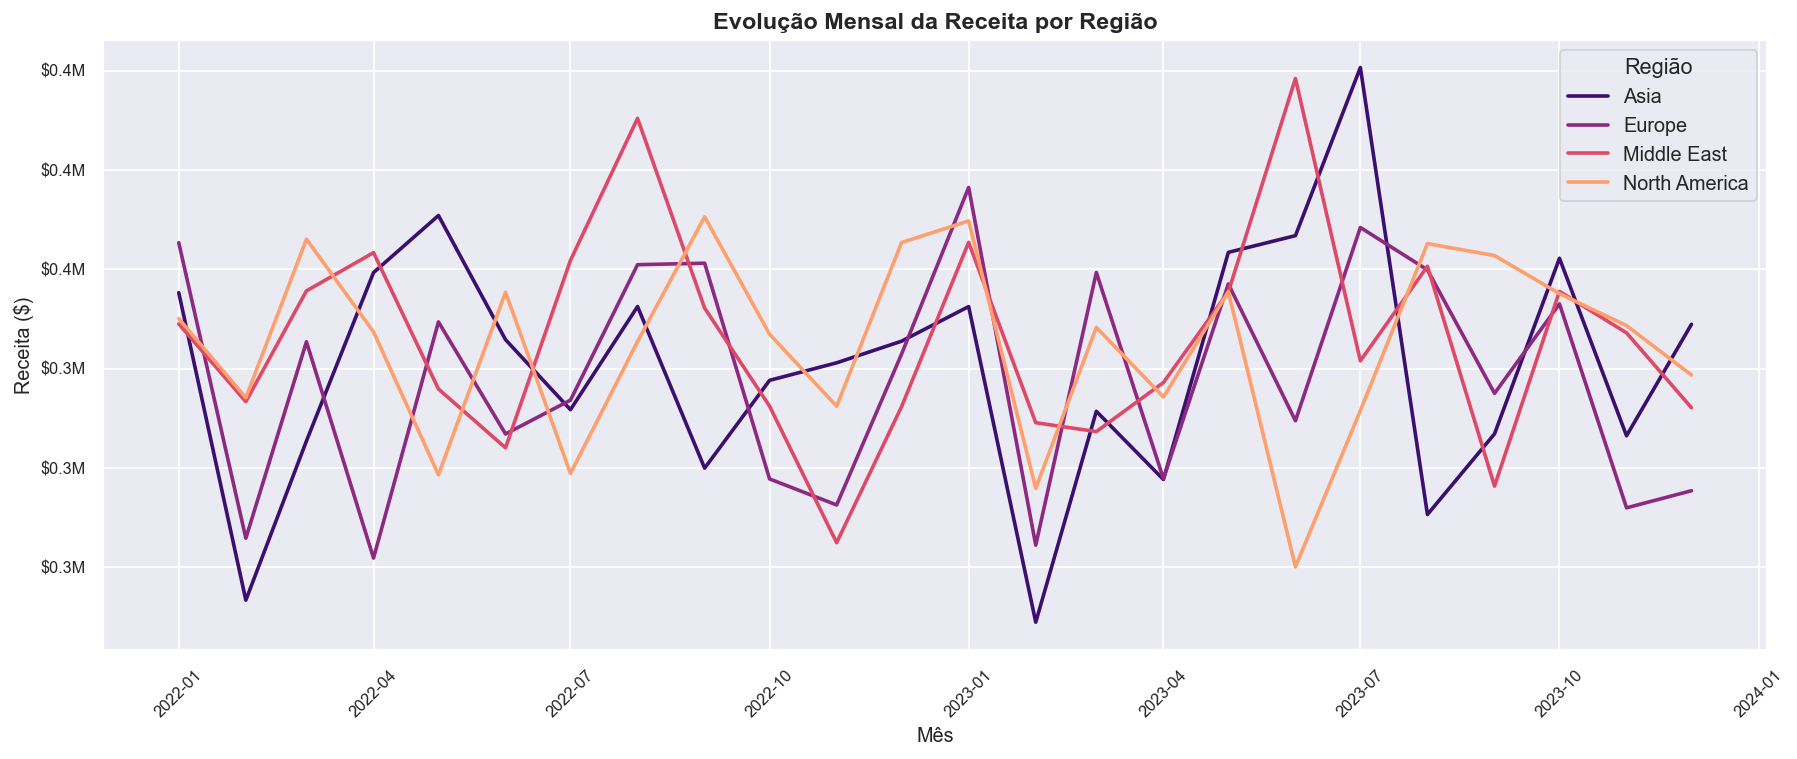

In [31]:
# ── 7.3 Evolução da receita por região ao longo do tempo ─────────────────────
reg_tempo = (df.groupby(['customer_region', df['order_date'].dt.to_period('M')], observed=True)
               ['total_revenue']
               .sum()
               .reset_index())
reg_tempo['order_date'] = reg_tempo['order_date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
regioes = reg_tempo['customer_region'].unique()
cores   = sns.color_palette('magma', len(regioes))

for regiao, cor in zip(regioes, cores):
    subset = reg_tempo[reg_tempo['customer_region'] == regiao]
    ax.plot(subset['order_date'], subset['total_revenue'],
            label=regiao, color=cor, linewidth=2)

ax.set_title('Evolução Mensal da Receita por Região')
ax.set_xlabel('Mês')
ax.set_ylabel('Receita ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(title='Região')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('receita_regional_tempo.png', bbox_inches='tight')
plt.show()

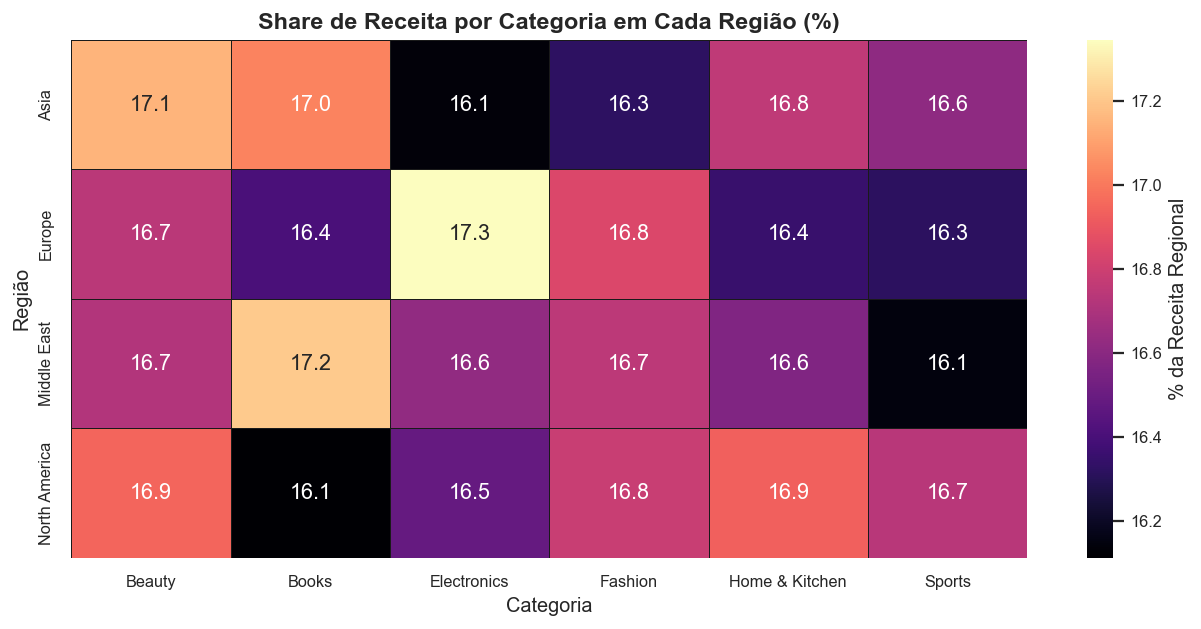

In [32]:
# ── 7.4 Preferência de categoria por região (heatmap) ────────────────────────
pivot_reg_cat = (df.groupby(['customer_region', 'product_category'], observed=True)
                   ['total_revenue']
                   .sum()
                   .unstack(fill_value=0))

# Normalizar por linha (% dentro de cada região)
pivot_pct = pivot_reg_cat.div(pivot_reg_cat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='magma',
            linewidths=0.5, linecolor='#1a1a1a',
            cbar_kws={'label': '% da Receita Regional'}, ax=ax)
ax.set_title('Share de Receita por Categoria em Cada Região (%)')
ax.set_xlabel('Categoria')
ax.set_ylabel('Região')
plt.tight_layout()
plt.savefig('heatmap_regiao_categoria.png', bbox_inches='tight')
plt.show()

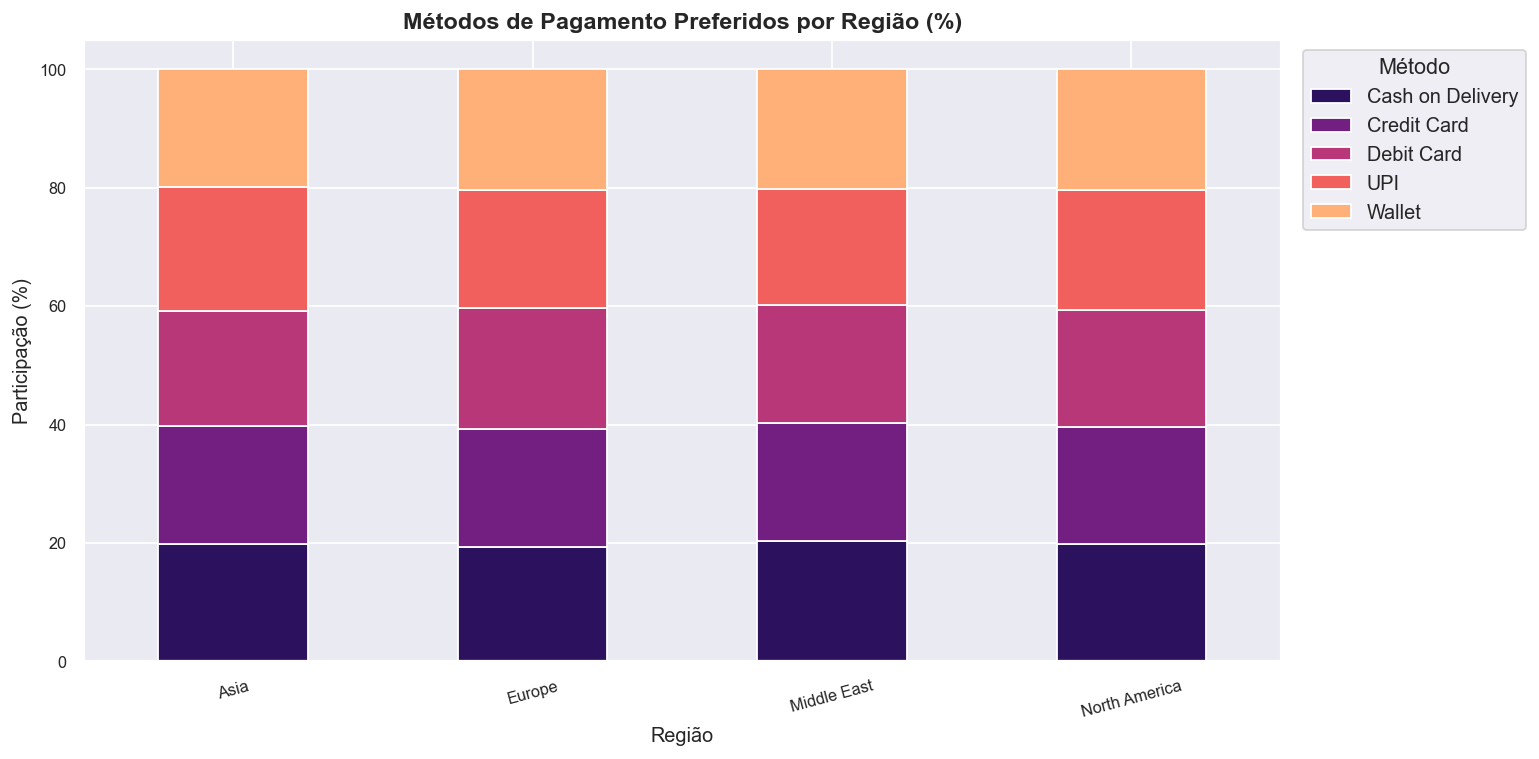

In [33]:
# ── 7.5 Métodos de pagamento preferidos por região ───────────────────────────
pag_reg = (df.groupby(['customer_region', 'payment_method'], observed=True)
             .size()
             .reset_index(name='count'))

pivot_pag = pag_reg.pivot(index='customer_region',
                          columns='payment_method',
                          values='count').fillna(0)

pivot_pag_pct = pivot_pag.div(pivot_pag.sum(axis=1), axis=0) * 100

pivot_pag_pct.plot(
    kind='bar', stacked=True,
    figsize=(12, 6),
    color=sns.color_palette('magma', len(pivot_pag_pct.columns))
)
plt.title('Métodos de Pagamento Preferidos por Região (%)')
plt.ylabel('Participação (%)')
plt.xlabel('Região')
plt.xticks(rotation=15)
plt.legend(title='Método', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pagamento_regiao.png', bbox_inches='tight')
plt.show()

---
## 8 · ⭐ Análise de Avaliações e Satisfação <a id='8'></a>

> **Tema bônus:** entender como as avaliações se distribuem entre categorias e regiões, e se existe correlação entre desconto e satisfação do cliente.

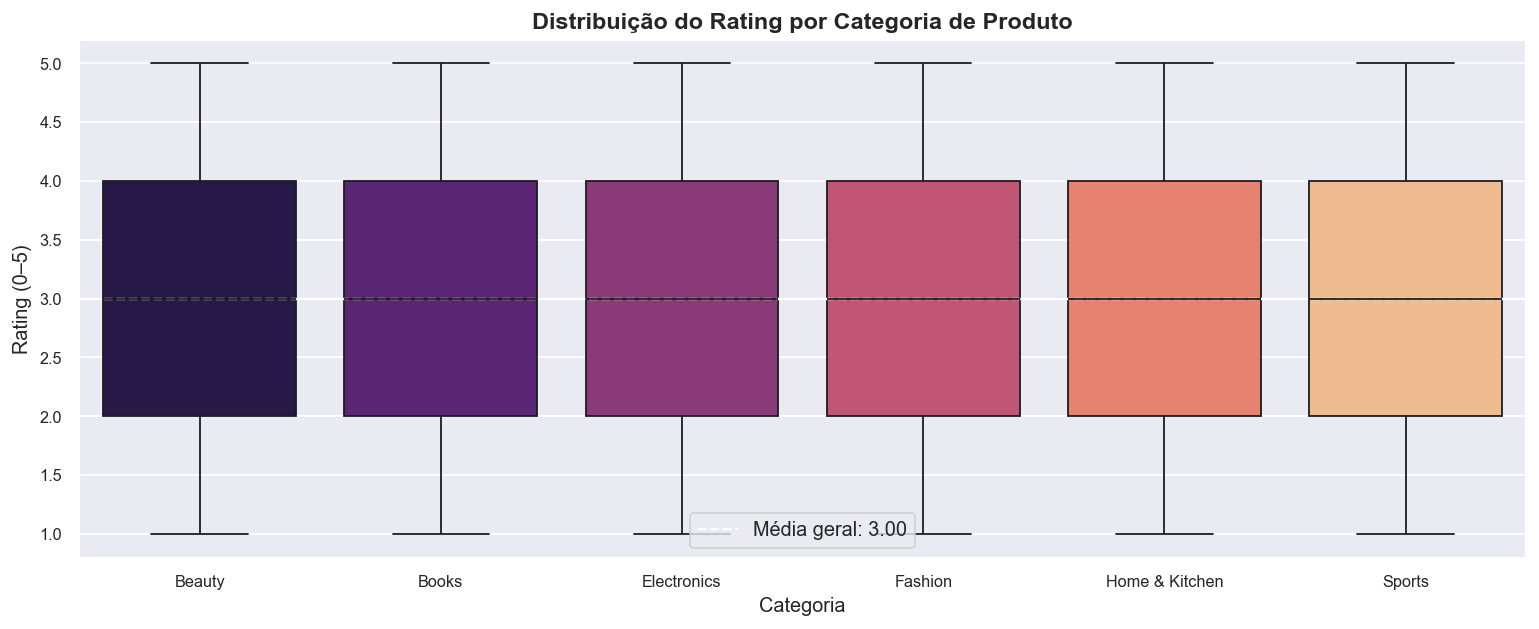

In [34]:
# ── 8.1 Distribuição do rating por categoria (boxplot) ───────────────────────
ordem = (df.groupby('product_category', observed=True)['rating']
           .median()
           .sort_values(ascending=False)
           .index.tolist())

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='product_category', y='rating',
            order=ordem, palette='magma', ax=ax,
            flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
ax.set_title('Distribuição do Rating por Categoria de Produto')
ax.set_xlabel('Categoria')
ax.set_ylabel('Rating (0–5)')
ax.axhline(df['rating'].mean(), color='white', linestyle='--',
           linewidth=1.3, label=f'Média geral: {df["rating"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('rating_categoria.png', bbox_inches='tight')
plt.show()

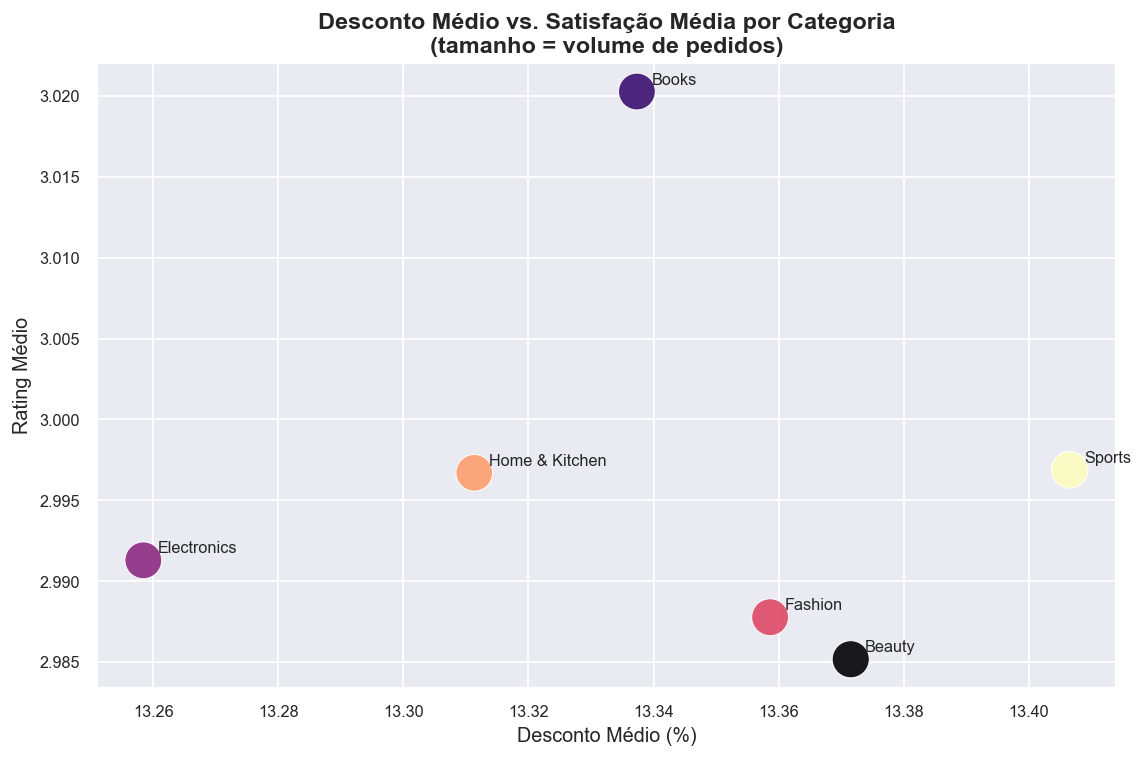

In [35]:
# ── 8.2 Desconto médio vs. rating médio por categoria ────────────────────────
sat_cat = (df.groupby('product_category', observed=True)
             .agg(rating_medio=('rating', 'mean'),
                  desconto_medio=('discount_percent', 'mean'),
                  n_pedidos=('order_id', 'count'))
             .reset_index())

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    sat_cat['desconto_medio'],
    sat_cat['rating_medio'],
    s=sat_cat['n_pedidos'] / 20,
    c=range(len(sat_cat)), cmap='magma',
    edgecolors='white', linewidth=0.6, alpha=0.9
)

for _, row in sat_cat.iterrows():
    ax.annotate(row['product_category'],
                (row['desconto_medio'], row['rating_medio']),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_title('Desconto Médio vs. Satisfação Média por Categoria\n(tamanho = volume de pedidos)')
ax.set_xlabel('Desconto Médio (%)')
ax.set_ylabel('Rating Médio')
plt.tight_layout()
plt.savefig('desconto_satisfacao.png', bbox_inches='tight')
plt.show()

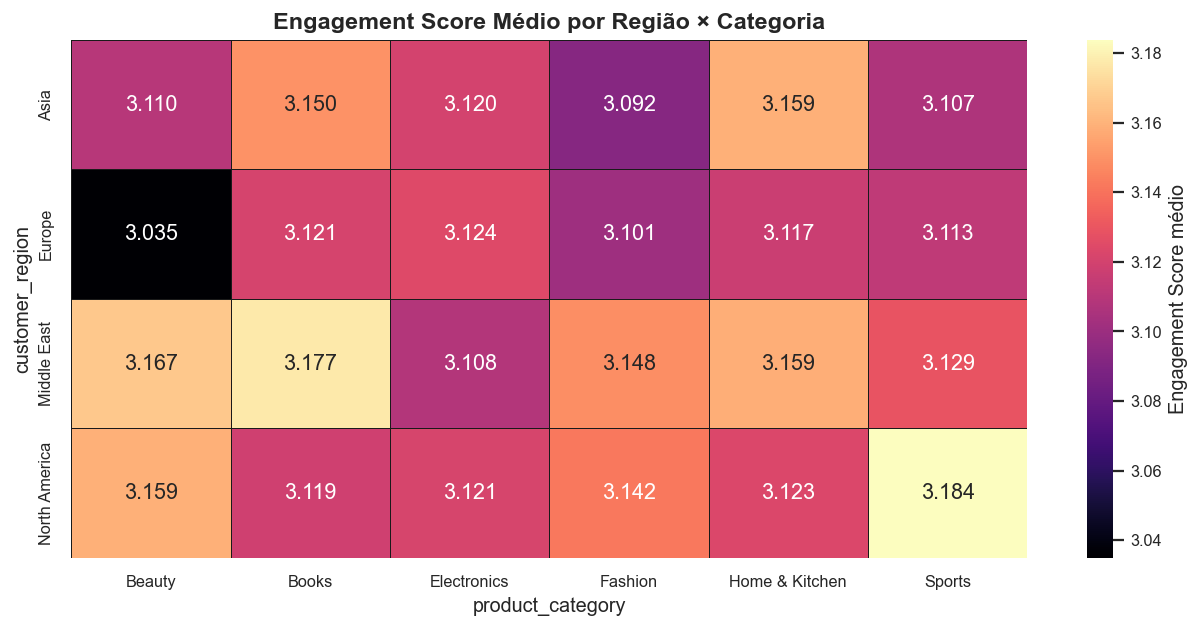

In [36]:
# ── 8.3 Engagement Score por região e categoria (heatmap) ────────────────────
eng_pivot = (df.groupby(['customer_region', 'product_category'], observed=True)
               ['engagement_score']
               .mean()
               .unstack())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(eng_pivot, annot=True, fmt='.3f', cmap='magma',
            linewidths=0.5, linecolor='#1a1a1a',
            cbar_kws={'label': 'Engagement Score médio'}, ax=ax)
ax.set_title('Engagement Score Médio por Região × Categoria')
plt.tight_layout()
plt.savefig('engagement_heatmap.png', bbox_inches='tight')
plt.show()

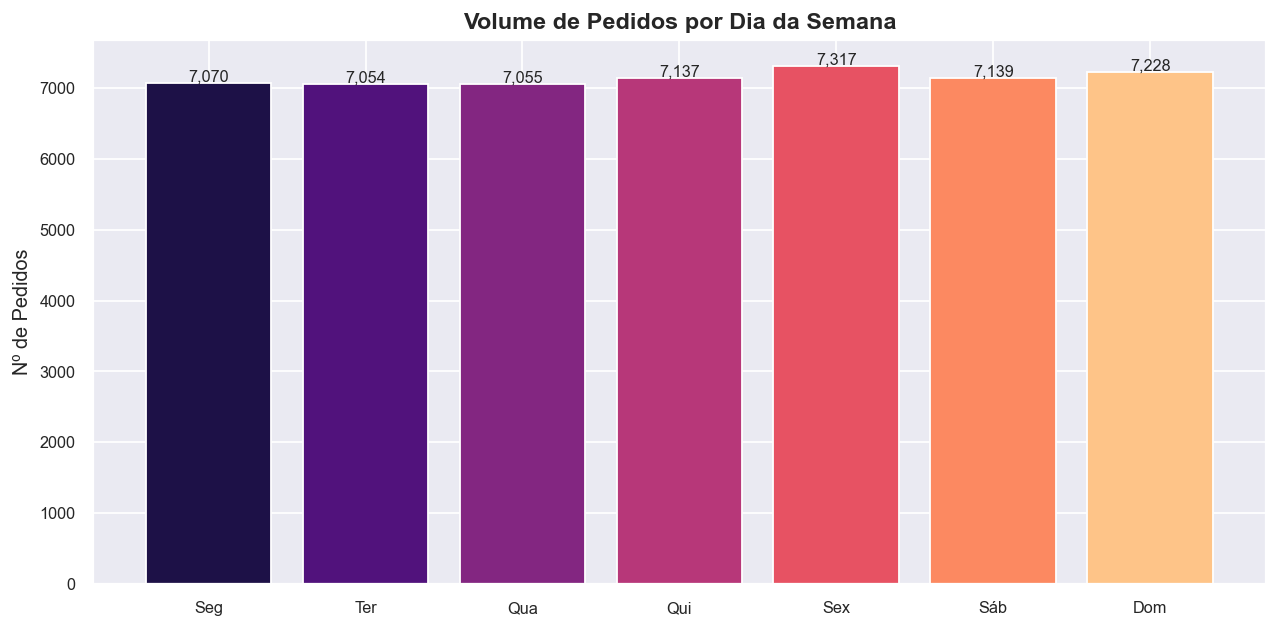

In [37]:
# ── 8.4 Volume de pedidos por dia da semana ───────────────────────────────────
ordem_semana = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
labels_pt    = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']

weekday_counts = (df['weekday']
                    .value_counts()
                    .reindex(ordem_semana))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels_pt, weekday_counts.values,
              color=sns.color_palette('magma', 7))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f'{bar.get_height():,.0f}',
            ha='center', fontsize=9)
ax.set_title('Volume de Pedidos por Dia da Semana')
ax.set_ylabel('Nº de Pedidos')
plt.tight_layout()
plt.savefig('pedidos_dia_semana.png', bbox_inches='tight')
plt.show()

---
## 9 · Exportação do Dataset Limpo <a id='9'></a>

In [ ]:
# ── Exportar dataset transformado ─────────────────────────────────────────────
OUTPUT_PATH = 'amazon_sales_cleaned.csv'

df.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Dataset exportado: {OUTPUT_PATH}')
print(f'   Shape final : {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f'\n📁 Colunas no dataset limpo:')
for col in df.columns:
    print(f'   · {col} ({df[col].dtype})')

---

## 📌 Sumário de Insights

| # | Tema | Insight |
|---|------|---------|
| 1 | EDA | Distribuição de preços e receita revela assimetria positiva — a maioria dos pedidos concentra-se em ticket baixo/médio |
| 2 | EDA | `total_revenue` possui forte correlação com `price` e `quantity_sold`, como esperado |
| 3 | Desconto | Faixas de desconto elevadas (21–30%) concentram a maior **receita perdida** absoluta |
| 4 | Desconto | Desconto e rating apresentam correlação fraca — descontos não garantem maior satisfação |
| 5 | Regional | North America lidera em receita total; Middle East apresenta o maior ticket médio |
| 6 | Regional | Preferências de categoria diferem por região — sinal de demanda localizada |
| 7 | Regional | Preferências de método de pagamento variam significativamente por região |
| 8 | Satisfação | Electronics e Sports tendem a ter os maiores engagement scores |
| 9 | Temporal | Volume de pedidos distribui-se uniformemente durante a semana, sem pico dominante |
